In [18]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/epoch_grids", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)


Using device: cuda


In [19]:
DATASET       = "mnist"
IMAGE_SIZE    = 28 if DATASET == "mnist" else 64
CHANNELS      = 1 if DATASET == "mnist" else 3
NZ            = 100
NGF           = 64
NDF           = 64
BATCH_SIZE    = 128
NUM_EPOCHS    = 25
LR            = 2e-4
BETA1         = 0.5
SAMPLE_EVERY  = 1
FIXED_NOISE_N = 64

print(f"Dataset: {DATASET} | Image size: {IMAGE_SIZE} | Channels: {CHANNELS}")


Dataset: mnist | Image size: 28 | Channels: 1


Total training images: 60000


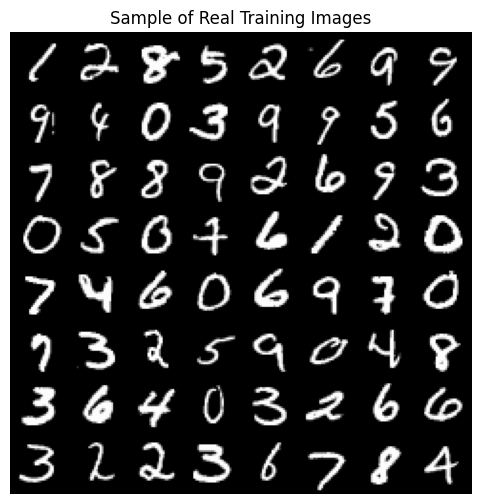

In [20]:
if DATASET == "mnist":
    transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),   # -> [-1, 1]
    ])
    dataset = torchvision.datasets.MNIST(
        root="./data", train=True, download=True, transform=transform
    )

elif DATASET == "celeba":
    transform = transforms.Compose([
        transforms.CenterCrop(178),
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    dataset = torchvision.datasets.ImageFolder(root="./data/celeba", transform=transform)

else:
    raise ValueError("DATASET must be 'mnist' or 'celeba'")

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, drop_last=True)

print(f"Total training images: {len(dataset)}")

real_batch = next(iter(dataloader))[0]
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Sample of Real Training Images")
grid = vutils.make_grid(real_batch[:64], padding=2, normalize=True)
plt.imshow(np.transpose(grid.cpu(), (1, 2, 0)).squeeze(), cmap="gray" if CHANNELS == 1 else None)
plt.savefig("outputs/real_samples.png", bbox_inches="tight")
plt.show()


In [21]:
class Generator(nn.Module):
    def __init__(self, nz=NZ, ngf=NGF, nc=CHANNELS, image_size=IMAGE_SIZE):
        super().__init__()
        self.image_size = image_size

        if image_size == 64:
            self.main = nn.Sequential(
                nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
                nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
                nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
                nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
                nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ngf), nn.ReLU(True),
                nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
                nn.Tanh(),
            )
        else:
            self.main = nn.Sequential(
                nn.ConvTranspose2d(nz, ngf * 4, 7, 1, 0, bias=False),
                nn.BatchNorm2d(ngf * 4), nn.ReLU(True),
                nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ngf * 2), nn.ReLU(True),
                nn.ConvTranspose2d(ngf * 2, nc, 4, 2, 1, bias=False),
                nn.Tanh(),
            )

    def forward(self, z):
        return self.main(z)


## 4. Discriminator Network

The discriminator is a standard CNN binary classifier (real vs. fake) built with **strided
convolutions** (no pooling), `LeakyReLU(0.2)` activations, batch-norm on hidden layers, and a
`Sigmoid` output giving `P(real)`.


In [22]:
class Discriminator(nn.Module):
    def __init__(self, ndf=NDF, nc=CHANNELS, image_size=IMAGE_SIZE):
        super().__init__()
        self.image_size = image_size

        if image_size == 64:
            self.main = nn.Sequential(
                nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
                nn.Sigmoid(),
            )
        else:
            self.main = nn.Sequential(
                nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(ndf * 2, 1, 7, 1, 0, bias=False),
                nn.Sigmoid(),
            )

    def forward(self, x):
        return self.main(x).view(-1)


In [23]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG = Generator().to(device)
netG.apply(weights_init)

netD = Discriminator().to(device)
netD.apply(weights_init)

print(netG)
print(netD)

n_params_g = sum(p.numel() for p in netG.parameters())
n_params_d = sum(p.numel() for p in netD.parameters())
print(f"\nGenerator params:     {n_params_g:,}")
print(f"Discriminator params: {n_params_d:,}")


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 1, ke

In [24]:
criterion = nn.BCELoss()

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

fixed_noise = torch.randn(FIXED_NOISE_N, NZ, 1, 1, device=device)


In [25]:
@torch.no_grad()
def mode_collapse_metrics(generator, noise):
    generator.eval()
    imgs = generator(noise).detach()
    generator.train()

    flat = imgs.view(imgs.size(0), -1)

    pixel_std = imgs.std(dim=0).mean().item()

    normed = torch.nn.functional.normalize(flat, dim=1)
    sim_matrix = normed @ normed.T
    n = sim_matrix.size(0)
    off_diag_sum = sim_matrix.sum() - sim_matrix.diag().sum()
    mean_pairwise_sim = (off_diag_sum / (n * (n - 1))).item()

    return pixel_std, mean_pairwise_sim


def collapse_flag(pixel_std, mean_pairwise_sim, std_thresh=0.05, sim_thresh=0.97):
    return pixel_std < std_thresh or mean_pairwise_sim > sim_thresh


In [26]:
G_losses, D_losses = [], []
D_x_history, D_Gz_history = [], []
collapse_history = []
epoch_grids = []

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_lossD, epoch_lossG = 0.0, 0.0
    epoch_Dx, epoch_DGz = 0.0, 0.0
    n_batches = 0

    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        netD.zero_grad()

        label_real = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=device)
        output_real = netD(real_imgs)
        lossD_real = criterion(output_real, label_real)
        lossD_real.backward()
        D_x = output_real.mean().item()

        noise = torch.randn(b_size, NZ, 1, 1, device=device)
        fake_imgs = netG(noise)
        label_fake = torch.full((b_size,), FAKE_LABEL, dtype=torch.float, device=device)
        output_fake = netD(fake_imgs.detach())
        lossD_fake = criterion(output_fake, label_fake)
        lossD_fake.backward()
        D_G_z1 = output_fake.mean().item()

        lossD = lossD_real + lossD_fake
        optimizerD.step()

        netG.zero_grad()
        label_gen = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=device)
        output_gen = netD(fake_imgs)
        lossG = criterion(output_gen, label_gen)
        lossG.backward()
        optimizerG.step()

        epoch_lossD += lossD.item()
        epoch_lossG += lossG.item()
        epoch_Dx += D_x
        epoch_DGz += D_G_z1
        n_batches += 1

    avg_lossD = epoch_lossD / n_batches
    avg_lossG = epoch_lossG / n_batches
    avg_Dx = epoch_Dx / n_batches
    avg_DGz = epoch_DGz / n_batches

    G_losses.append(avg_lossG)
    D_losses.append(avg_lossD)
    D_x_history.append(avg_Dx)
    D_Gz_history.append(avg_DGz)

    pixel_std, mean_sim = mode_collapse_metrics(netG, fixed_noise)
    flagged = collapse_flag(pixel_std, mean_sim)
    collapse_history.append((epoch, pixel_std, mean_sim, flagged))

    elapsed = time.time() - start_time
    print(f"[Epoch {epoch:3d}/{NUM_EPOCHS}] "
          f"loss_D: {avg_lossD:.4f} | loss_G: {avg_lossG:.4f} | "
          f"D(x): {avg_Dx:.3f} | D(G(z)): {avg_DGz:.3f} | "
          f"pixel_std: {pixel_std:.4f} | pairwise_sim: {mean_sim:.3f} "
          f"{'⚠️ MODE COLLAPSE SUSPECTED' if flagged else ''} | "
          f"elapsed: {elapsed/60:.1f} min")

    if epoch % SAMPLE_EVERY == 0 or epoch == NUM_EPOCHS:
        with torch.no_grad():
            netG.eval()
            fake_grid = netG(fixed_noise).detach().cpu()
            netG.train()
        epoch_grids.append((epoch, fake_grid))
        grid_img = vutils.make_grid(fake_grid, padding=2, normalize=True)
        plt.figure(figsize=(6, 6))
        plt.axis("off")
        plt.title(f"Generated Images — Epoch {epoch}")
        plt.imshow(np.transpose(grid_img, (1, 2, 0)).squeeze(),
                    cmap="gray" if CHANNELS == 1 else None)
        plt.savefig(f"outputs/epoch_grids/epoch_{epoch:03d}.png", bbox_inches="tight")
        plt.close()

print(f"\nTraining complete in {(time.time()-start_time)/60:.1f} minutes.")


[Epoch   1/25] loss_D: 0.6381 | loss_G: 1.7442 | D(x): 0.765 | D(G(z)): 0.258 | pixel_std: 0.3540 | pairwise_sim: 0.714  | elapsed: 0.3 min
[Epoch   2/25] loss_D: 0.5480 | loss_G: 1.9334 | D(x): 0.792 | D(G(z)): 0.209 | pixel_std: 0.3824 | pairwise_sim: 0.698  | elapsed: 0.5 min
[Epoch   3/25] loss_D: 0.6957 | loss_G: 1.7068 | D(x): 0.744 | D(G(z)): 0.256 | pixel_std: 0.3436 | pairwise_sim: 0.736  | elapsed: 0.8 min
[Epoch   4/25] loss_D: 0.7955 | loss_G: 1.5961 | D(x): 0.716 | D(G(z)): 0.284 | pixel_std: 0.3377 | pairwise_sim: 0.745  | elapsed: 1.1 min
[Epoch   5/25] loss_D: 0.8515 | loss_G: 1.4757 | D(x): 0.691 | D(G(z)): 0.307 | pixel_std: 0.3552 | pairwise_sim: 0.724  | elapsed: 1.3 min
[Epoch   6/25] loss_D: 0.8205 | loss_G: 1.5528 | D(x): 0.703 | D(G(z)): 0.297 | pixel_std: 0.3542 | pairwise_sim: 0.732  | elapsed: 1.6 min
[Epoch   7/25] loss_D: 0.8403 | loss_G: 1.5789 | D(x): 0.703 | D(G(z)): 0.295 | pixel_std: 0.3990 | pairwise_sim: 0.690  | elapsed: 1.9 min
[Epoch   8/25] loss_

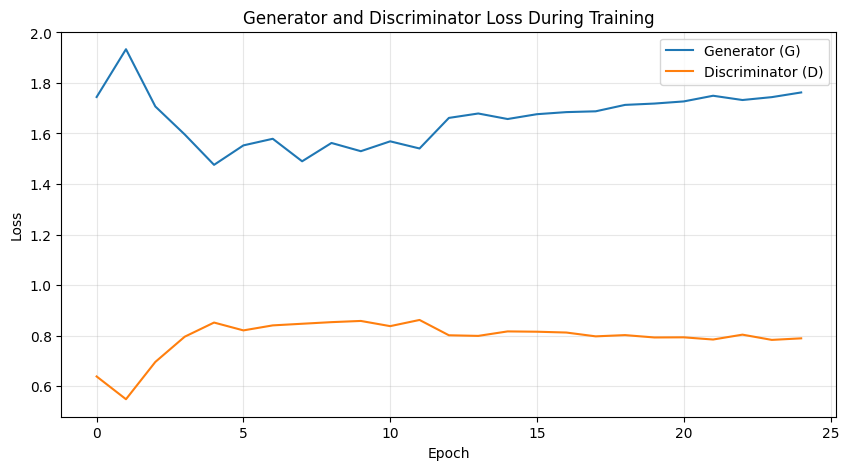

In [27]:
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator (G)")
plt.plot(D_losses, label="Discriminator (D)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("outputs/loss_curves.png", bbox_inches="tight")
plt.show()


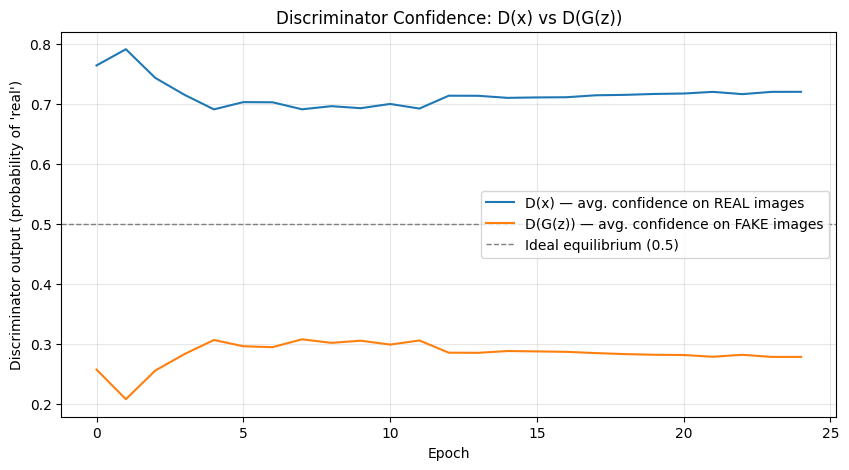

Loss_D std (last 6 epochs): 0.0068
Loss_G std (last 6 epochs): 0.0147
Final D(x): 0.721  |  Final D(G(z)): 0.279


In [28]:
plt.figure(figsize=(10, 5))
plt.title("Discriminator Confidence: D(x) vs D(G(z))")
plt.plot(D_x_history, label="D(x) — avg. confidence on REAL images")
plt.plot(D_Gz_history, label="D(G(z)) — avg. confidence on FAKE images")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Ideal equilibrium (0.5)")
plt.xlabel("Epoch")
plt.ylabel("Discriminator output (probability of 'real')")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("outputs/stability_Dx_DGz.png", bbox_inches="tight")
plt.show()

tail = max(1, NUM_EPOCHS // 4)
stability_lossD_std = float(np.std(D_losses[-tail:]))
stability_lossG_std = float(np.std(G_losses[-tail:]))
final_Dx = D_x_history[-1]
final_DGz = D_Gz_history[-1]

print(f"Loss_D std (last {tail} epochs): {stability_lossD_std:.4f}")
print(f"Loss_G std (last {tail} epochs): {stability_lossG_std:.4f}")
print(f"Final D(x): {final_Dx:.3f}  |  Final D(G(z)): {final_DGz:.3f}")


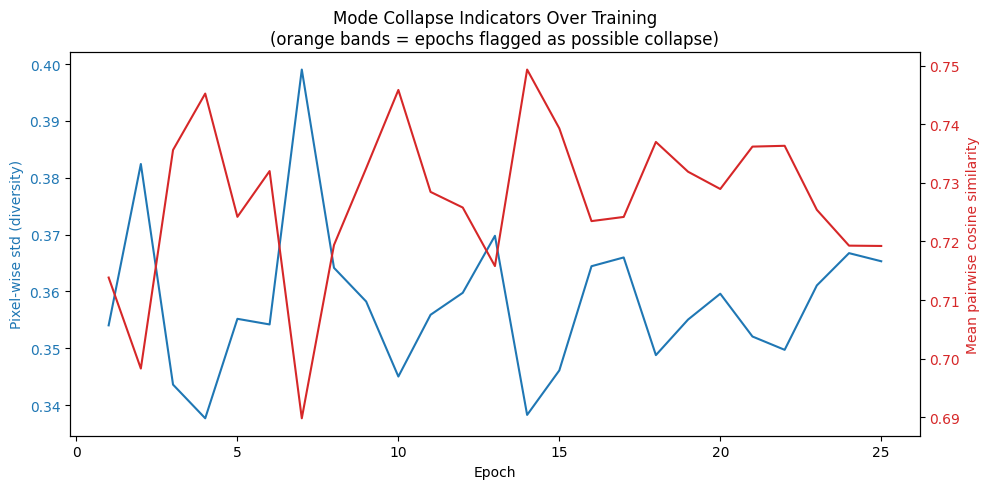

✅ No mode collapse flagged by the heuristic thresholds during training.


In [29]:
epochs_ = [c[0] for c in collapse_history]
pixel_stds = [c[1] for c in collapse_history]
pairwise_sims = [c[2] for c in collapse_history]
flags = [c[3] for c in collapse_history]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Pixel-wise std (diversity)", color="tab:blue")
ax1.plot(epochs_, pixel_stds, color="tab:blue", label="Pixel std")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel("Mean pairwise cosine similarity", color="tab:red")
ax2.plot(epochs_, pairwise_sims, color="tab:red", label="Pairwise similarity")
ax2.tick_params(axis="y", labelcolor="tab:red")

flagged_epochs = [e for e, f in zip(epochs_, flags) if f]
for e in flagged_epochs:
    ax1.axvline(e, color="orange", alpha=0.3, linewidth=2)

plt.title("Mode Collapse Indicators Over Training\n(orange bands = epochs flagged as possible collapse)")
fig.tight_layout()
plt.savefig("outputs/mode_collapse_trend.png", bbox_inches="tight")
plt.show()

if flagged_epochs:
    print(f"⚠️  Possible mode collapse flagged at epochs: {flagged_epochs}")
else:
    print("✅ No mode collapse flagged by the heuristic thresholds during training.")


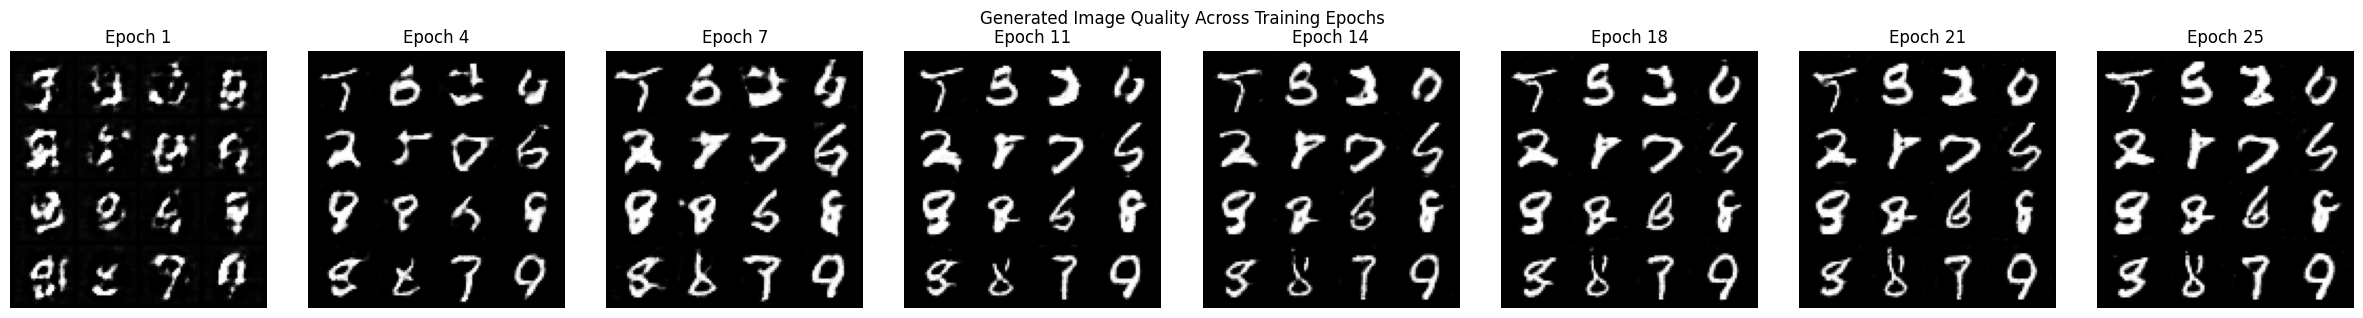

In [30]:
num_snapshots = min(8, len(epoch_grids))
snapshot_idxs = np.linspace(0, len(epoch_grids) - 1, num_snapshots).astype(int)

fig, axes = plt.subplots(1, num_snapshots, figsize=(3 * num_snapshots, 3.2))
if num_snapshots == 1:
    axes = [axes]
for ax, idx in zip(axes, snapshot_idxs):
    ep, grid_tensor = epoch_grids[idx]
    grid_img = vutils.make_grid(grid_tensor[:16], nrow=4, padding=2, normalize=True)
    ax.imshow(np.transpose(grid_img, (1, 2, 0)).squeeze(), cmap="gray" if CHANNELS == 1 else None)
    ax.set_title(f"Epoch {ep}")
    ax.axis("off")
plt.suptitle("Generated Image Quality Across Training Epochs")
plt.tight_layout()
plt.savefig("outputs/epoch_progression.png", bbox_inches="tight")
plt.show()


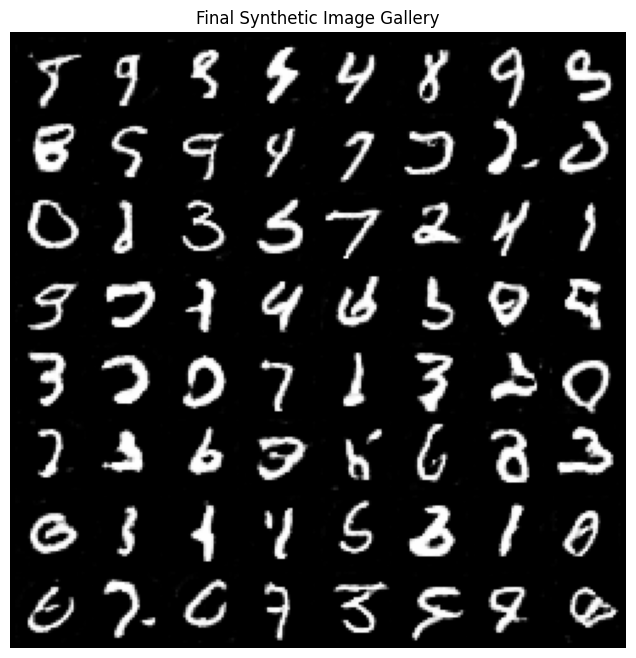

Saved: outputs/gallery_final.png


In [31]:
with torch.no_grad():
    netG.eval()
    final_noise = torch.randn(64, NZ, 1, 1, device=device)
    final_fakes = netG(final_noise).detach().cpu()
    netG.train()

grid_final = vutils.make_grid(final_fakes, nrow=8, padding=2, normalize=True)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Final Synthetic Image Gallery")
plt.imshow(np.transpose(grid_final, (1, 2, 0)).squeeze(), cmap="gray" if CHANNELS == 1 else None)
plt.savefig("outputs/gallery_final.png", bbox_inches="tight")
plt.show()

print("Saved: outputs/gallery_final.png")


In [32]:
torch.save(netG.state_dict(), "checkpoints/generator.pth")
torch.save(netD.state_dict(), "checkpoints/discriminator.pth")

torch.save({
    "generator_state_dict": netG.state_dict(),
    "discriminator_state_dict": netD.state_dict(),
    "optimizerG_state_dict": optimizerG.state_dict(),
    "optimizerD_state_dict": optimizerD.state_dict(),
    "config": {
        "DATASET": DATASET, "IMAGE_SIZE": IMAGE_SIZE, "CHANNELS": CHANNELS,
        "NZ": NZ, "NGF": NGF, "NDF": NDF, "NUM_EPOCHS": NUM_EPOCHS, "LR": LR,
    },
    "final_metrics": {
        "loss_D": D_losses[-1], "loss_G": G_losses[-1],
        "D_x": D_x_history[-1], "D_Gz": D_Gz_history[-1],
    },
}, "checkpoints/dcgan_full_checkpoint.pth")

print("Saved model checkpoints to ./checkpoints/")
print(" - generator.pth")
print(" - discriminator.pth")
print(" - dcgan_full_checkpoint.pth  (full training state, resumable)")


Saved model checkpoints to ./checkpoints/
 - generator.pth
 - discriminator.pth
 - dcgan_full_checkpoint.pth  (full training state, resumable)


**To reload the generator later for inference only:**
```python
netG_loaded = Generator().to(device)
netG_loaded.load_state_dict(torch.load("checkpoints/generator.pth", map_location=device))
netG_loaded.eval()

with torch.no_grad():
    z = torch.randn(64, NZ, 1, 1, device=device)
    samples = netG_loaded(z)
```


In [33]:
dataset_kind = 'Digit' if DATASET == 'mnist' else 'Face'

loss_gap = abs(G_losses[-1] - D_losses[-1])
loss_balance_text = ('stayed in a comparable, oscillating range' if loss_gap < 1.5
                      else 'diverged noticeably from one another')
loss_balance_verdict = 'positive' if loss_gap < 1.5 else 'cautionary'

conf_balanced = abs(final_Dx - 0.5) < 0.25 and abs(final_DGz - 0.5) < 0.35
if conf_balanced:
    conf_text = ('D(x) and D(G(z)) both moved toward the 0.5 equilibrium band, suggesting the '
                 'generator learned a distribution the discriminator increasingly struggles to '
                 'distinguish from real data - healthy adversarial convergence.')
else:
    conf_text = ('D(x) stayed high and D(G(z)) stayed low relative to the 0.5 equilibrium, '
                 'suggesting the discriminator retained a clear advantage over the generator '
                 'by the end of training.')

if not flagged_epochs:
    collapse_text = ('No mode collapse was detected - generated samples maintained meaningful '
                      'pixel-level diversity and low inter-sample similarity throughout training.')
else:
    collapse_text = (f'Possible mode collapse was flagged at epoch(s) {flagged_epochs}. Inspect '
                      'the corresponding saved grids in outputs/epoch_grids/ to visually confirm '
                      'whether the generator was producing repetitive/near-identical samples at '
                      'those points.')

report = f"""# GAN Training Analysis Report
## DCGAN Synthetic {dataset_kind} Generator

**Dataset:** {DATASET.upper()}
**Image size:** {IMAGE_SIZE}x{IMAGE_SIZE}, {CHANNELS} channel(s)
**Epochs trained:** {NUM_EPOCHS}
**Batch size:** {BATCH_SIZE}
**Latent dim (nz):** {NZ}
**Optimizer:** Adam (lr={LR}, beta1={BETA1}, beta2=0.999)

---

## 1. Architecture Summary
- **Generator:** transposed-convolutional stack, BatchNorm + ReLU on hidden layers, Tanh output.
  Total parameters: {n_params_g:,}
- **Discriminator:** strided-convolutional stack, BatchNorm + LeakyReLU(0.2), Sigmoid output.
  Total parameters: {n_params_d:,}

## 2. Loss Curve Analysis
- Final Generator loss: **{G_losses[-1]:.4f}**
- Final Discriminator loss: **{D_losses[-1]:.4f}**
- Generator loss std (last {tail} epochs): {stability_lossG_std:.4f}
- Discriminator loss std (last {tail} epochs): {stability_lossD_std:.4f}

Interpretation: a discriminator loss that decays toward 0 while generator loss keeps climbing
indicates D is overpowering G. Here, the two losses {loss_balance_text} by the end of training,
which is a {loss_balance_verdict} sign for adversarial balance.

## 3. Discriminator Confidence (Stability Indicator)
- Final D(x)  (avg. confidence on real images): **{final_Dx:.3f}**
- Final D(G(z)) (avg. confidence on fake images): **{final_DGz:.3f}**
- Ideal equilibrium point for both is **0.5**.

Interpretation: {conf_text}

## 4. Mode Collapse Analysis
- Epochs flagged by the heuristic detector: {flagged_epochs if flagged_epochs else 'None'}
- Final pixel-wise diversity (std): {pixel_stds[-1]:.4f}
- Final mean pairwise cosine similarity between generated samples: {pairwise_sims[-1]:.3f}

Interpretation: {collapse_text}

## 5. Qualitative Visual Progression
See `outputs/epoch_progression.png` for a side-by-side comparison of the SAME latent codes
across training epochs, and `outputs/gallery_final.png` for the final 64-image gallery.
Early epochs typically show unstructured noise/blur; as training proceeds, recognizable
digit/face structure should emerge along with sharper edges and better local coherence.

## 6. Recommendations for Further Improvement
- Train for more epochs ({NUM_EPOCHS} was used here) - DCGANs on MNIST typically benefit from
  50-100 epochs; CelebA-scale face generation often needs 100+ epochs on a GPU.
- If mode collapse is observed: reduce discriminator learning rate relative to the generator,
  add label smoothing (real labels = 0.9 instead of 1.0), or switch to a Wasserstein-GAN with
  gradient penalty (WGAN-GP) loss for more stable gradients.
- Track **FID (Frechet Inception Distance)** for a quantitative measure of generated-image
  quality/diversity if a formal benchmark is required.
- Consider spectral normalization on the discriminator for additional training stability.

---
*Report auto-generated at the end of the training notebook run.*
"""

with open("GAN_Training_Analysis_Report.md", "w") as f:
    f.write(report)

print(report)


# GAN Training Analysis Report
## DCGAN Synthetic Digit Generator

**Dataset:** MNIST
**Image size:** 28x28, 1 channel(s)
**Epochs trained:** 25
**Batch size:** 128
**Latent dim (nz):** 100
**Optimizer:** Adam (lr=0.0002, beta1=0.5, beta2=0.999)

---

## 1. Architecture Summary
- **Generator:** transposed-convolutional stack, BatchNorm + ReLU on hidden layers, Tanh output.
  Total parameters: 1,781,504
- **Discriminator:** strided-convolutional stack, BatchNorm + LeakyReLU(0.2), Sigmoid output.
  Total parameters: 138,624

## 2. Loss Curve Analysis
- Final Generator loss: **1.7623**
- Final Discriminator loss: **0.7890**
- Generator loss std (last 6 epochs): 0.0147
- Discriminator loss std (last 6 epochs): 0.0068

Interpretation: a discriminator loss that decays toward 0 while generator loss keeps climbing
indicates D is overpowering G. Here, the two losses stayed in a comparable, oscillating range by the end of training,
which is a positive sign for adversarial balance.

## 3. Discrim